# **Census Income Prediction: Classifying Income Levels Based on Demographic Census Data**

# **Loading Files**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Dataset and Cleaning**

In [ ]:
# Define column names based on dataset documentation
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load the dataset
# Note: The dataset contains leading spaces after commas, so we use sep=', '
df = pd.read_csv('adult.data', names=columns, sep=', ', engine='python')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## **Dataset Cleaning**

In [ ]:
# 1. Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# 2. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# 3. Drop rows with missing values (standard for this specific dataset)
df.dropna(inplace=True)

# 4. Clean the target variable (remove trailing dots if any)
df['income'] = df['income'].str.rstrip('.')

print(f"Cleaned Dataset Shape: {df.shape}")

Missing values per column:
 age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64
Cleaned Dataset Shape: (30162, 15)


# **Exploratory Data Analysis**

## **Univariate Analysis (Distribution of Features)**

/tmp/ipython-input-222471539.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='Set2')
/tmp/ipython-input-222471539.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


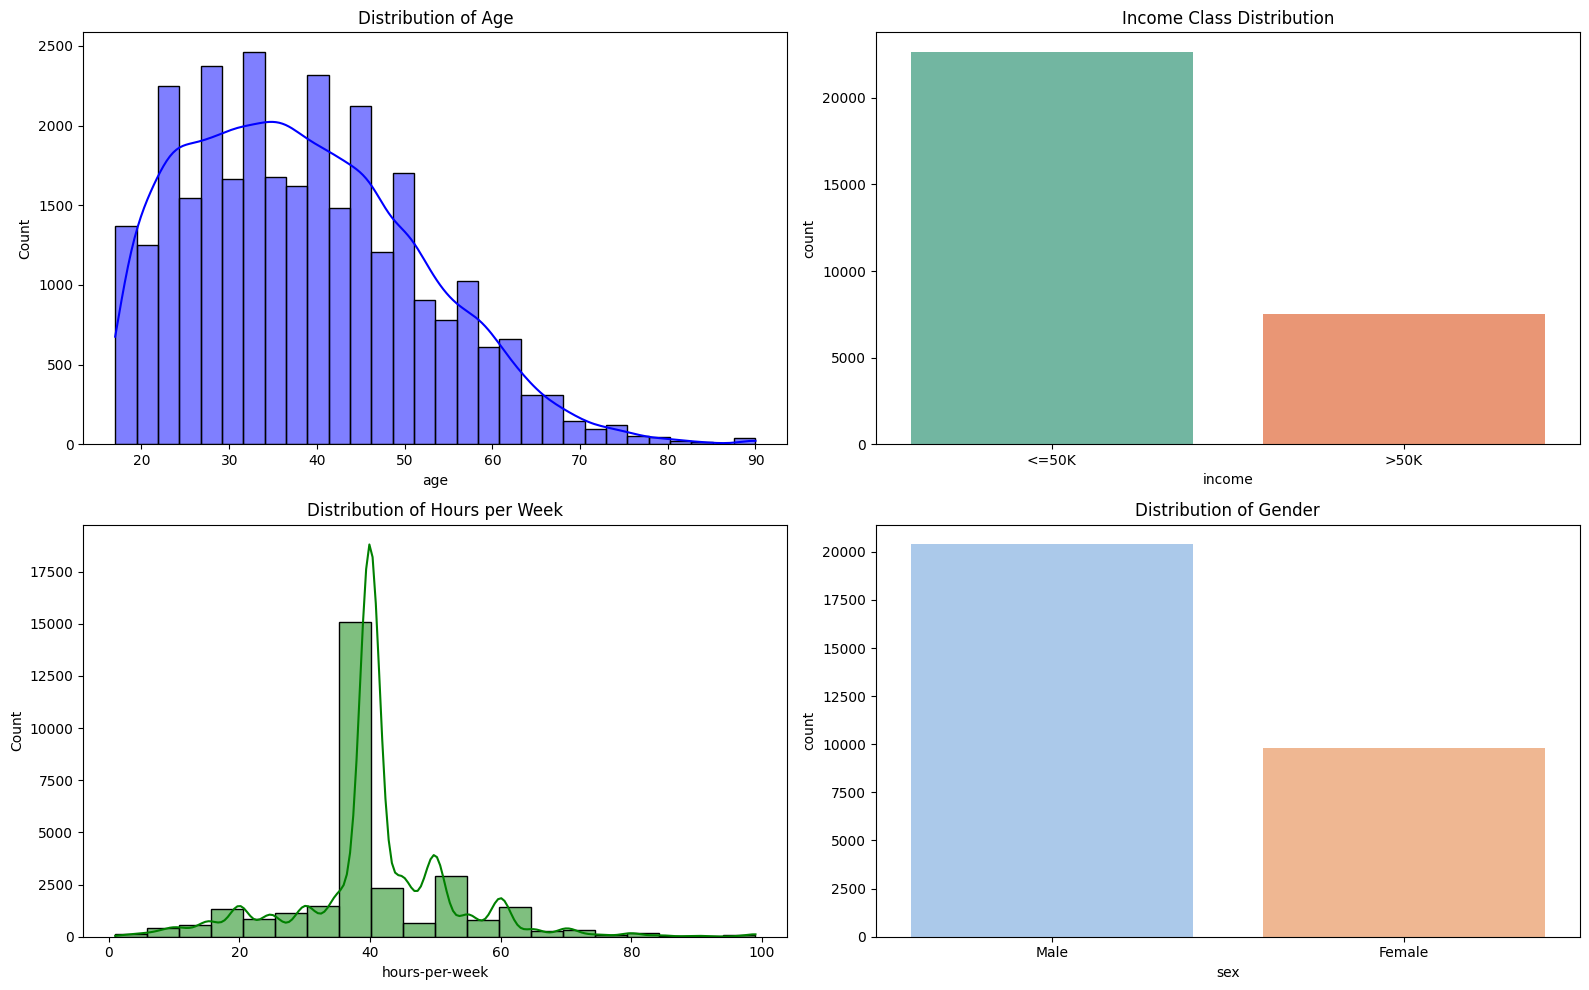

In [ ]:
plt.figure(figsize=(16, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Distribution of Age')

# Income Distribution (Target Variable)
plt.subplot(2, 2, 2)
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Income Class Distribution')

# Hours Per Week
plt.subplot(2, 2, 3)
sns.histplot(df['hours-per-week'], bins=20, kde=True, color='green')
plt.title('Distribution of Hours per Week')

# Sex Distribution
plt.subplot(2, 2, 4)
sns.countplot(x='sex', data=df, palette='pastel')
plt.title('Distribution of Gender')

plt.tight_layout()
plt.show()

## **Bivariate Analysis (Relationships with Income)**

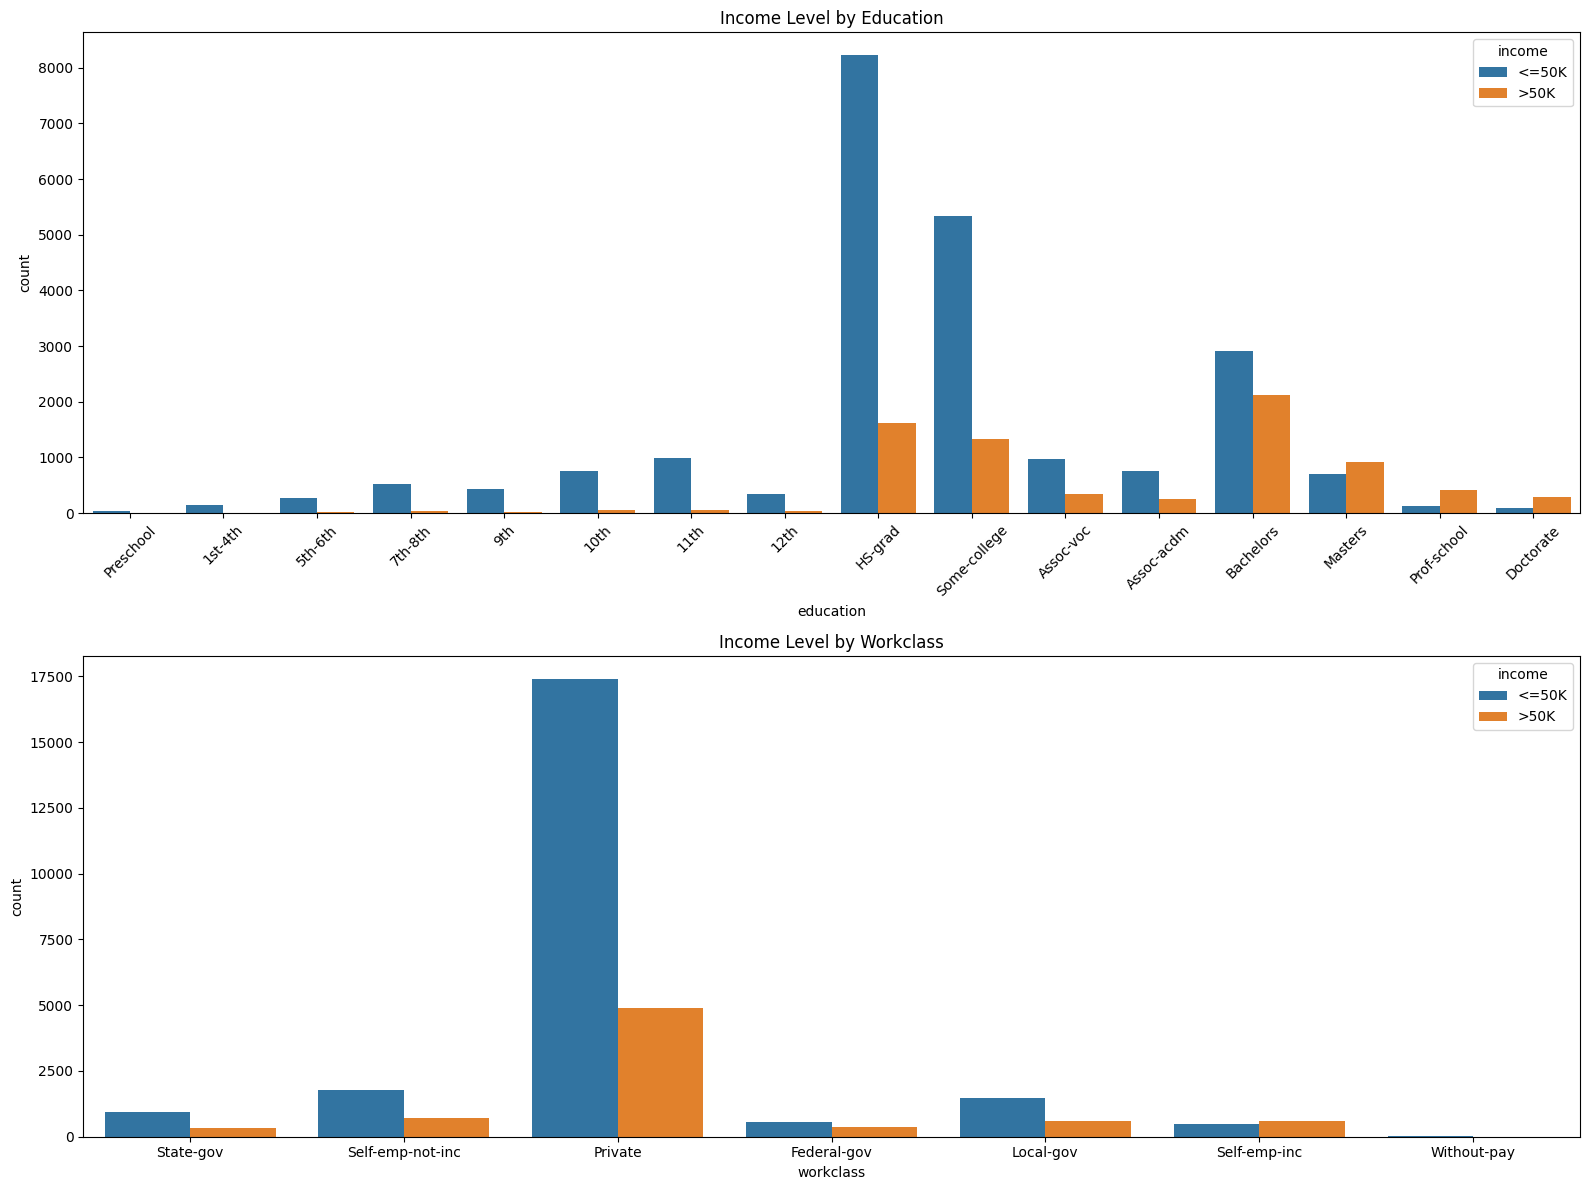

In [ ]:
plt.figure(figsize=(16, 12))

# Education vs Income
plt.subplot(2, 1, 1)
# Sorting by education-num ensures the levels are in order (e.g., HS-grad < Bachelors)
order = df.groupby('education')['education-num'].mean().sort_values().index
sns.countplot(x='education', hue='income', data=df, order=order)
plt.xticks(rotation=45)
plt.title('Income Level by Education')

# Workclass vs Income
plt.subplot(2, 1, 2)
sns.countplot(x='workclass', hue='income', data=df)
plt.title('Income Level by Workclass')

plt.tight_layout()
plt.show()

## **Numerical Correlations**

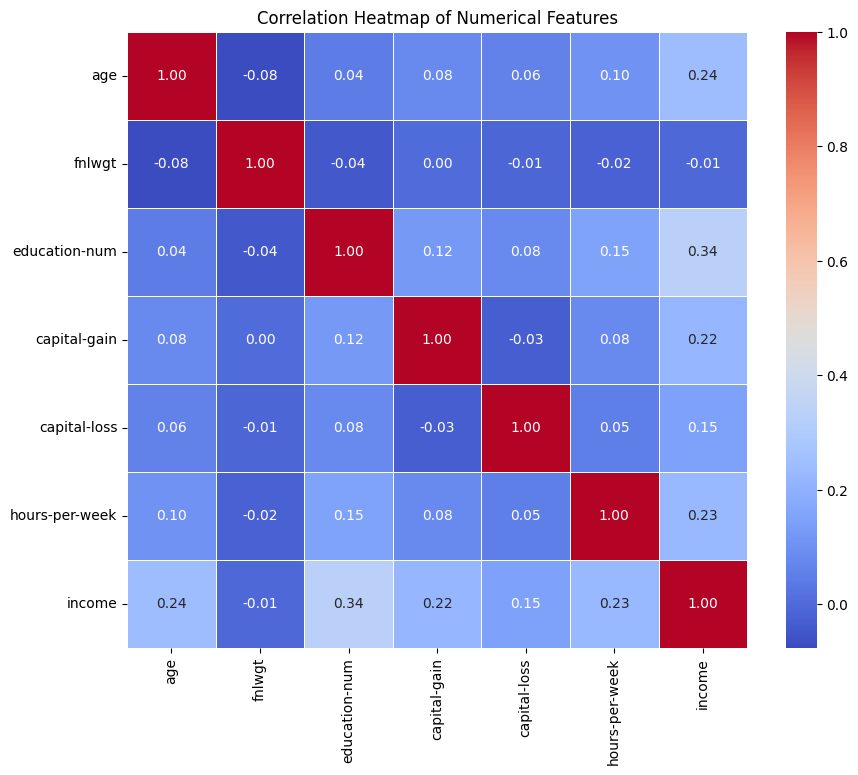

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy for correlation analysis
df_corr = df.copy()
# Encode income to numeric: <=50K is 0, >50K is 1
df_corr['income'] = df_corr['income'].map({'<=50K': 0, '>50K': 1})

# Select only numerical columns for correlation calculation
numeric_cols = df_corr.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## **Multivariate Analysis (Hours vs. Age vs. Income)**

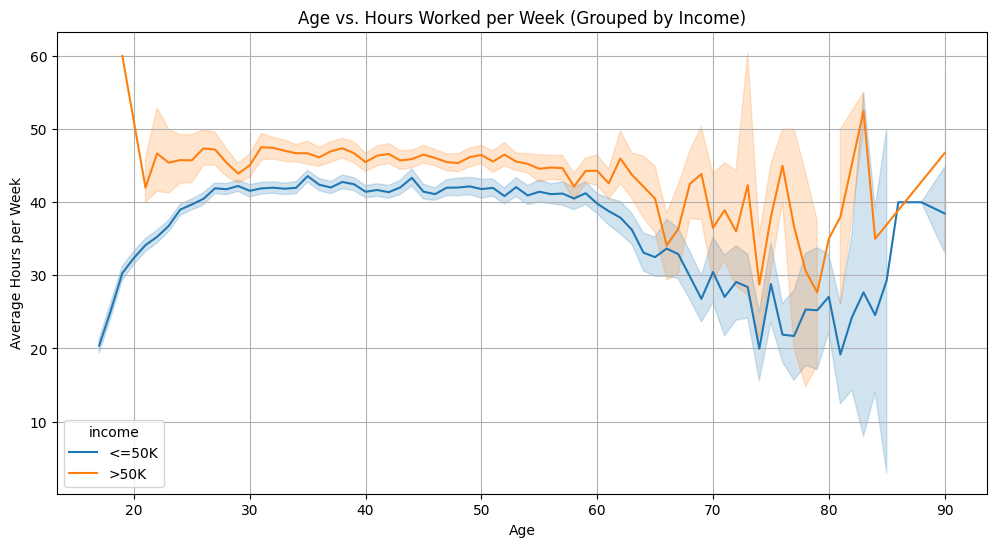

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='hours-per-week', hue='income', data=df)
plt.title('Age vs. Hours Worked per Week (Grouped by Income)')
plt.xlabel('Age')
plt.ylabel('Average Hours per Week')
plt.grid(True)
plt.show()

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data (assuming df is already loaded)
# Cleaning target variable and mapping to 0 and 1
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
le = LabelEncoder()
y = le.fit_transform(df['income'])
X = df.drop(['income', 'fnlwgt'], axis=1) # Dropping fnlwgt as it's usually irrelevant

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training and Evaluation**

This section focuses on training various classification models to predict income levels. We will use a robust pipeline that includes preprocessing steps for both numerical and categorical features. The models selected for evaluation are:

*   **Logistic Regression**: A linear model often used as a baseline for binary classification.
*   **Random Forest**: An ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction.
*   **XGBoost**: An optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.

We will evaluate these models based on standard classification metrics such as accuracy, precision, recall, and F1-score, and visualize their performance using confusion matrices and ROC curves.


Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4503
           1       0.76      0.62      0.68      1530

    accuracy                           0.85      6033
   macro avg       0.82      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033


Report for Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4503
           1       0.71      0.65      0.68      1530

    accuracy                           0.84      6033
   macro avg       0.80      0.78      0.79      6033
weighted avg       0.84      0.84      0.84      6033



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:44:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Report for XGBoost:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      4503
           1       0.79      0.67      0.73      1530

    accuracy                           0.87      6033
   macro avg       0.84      0.81      0.82      6033
weighted avg       0.87      0.87      0.87      6033



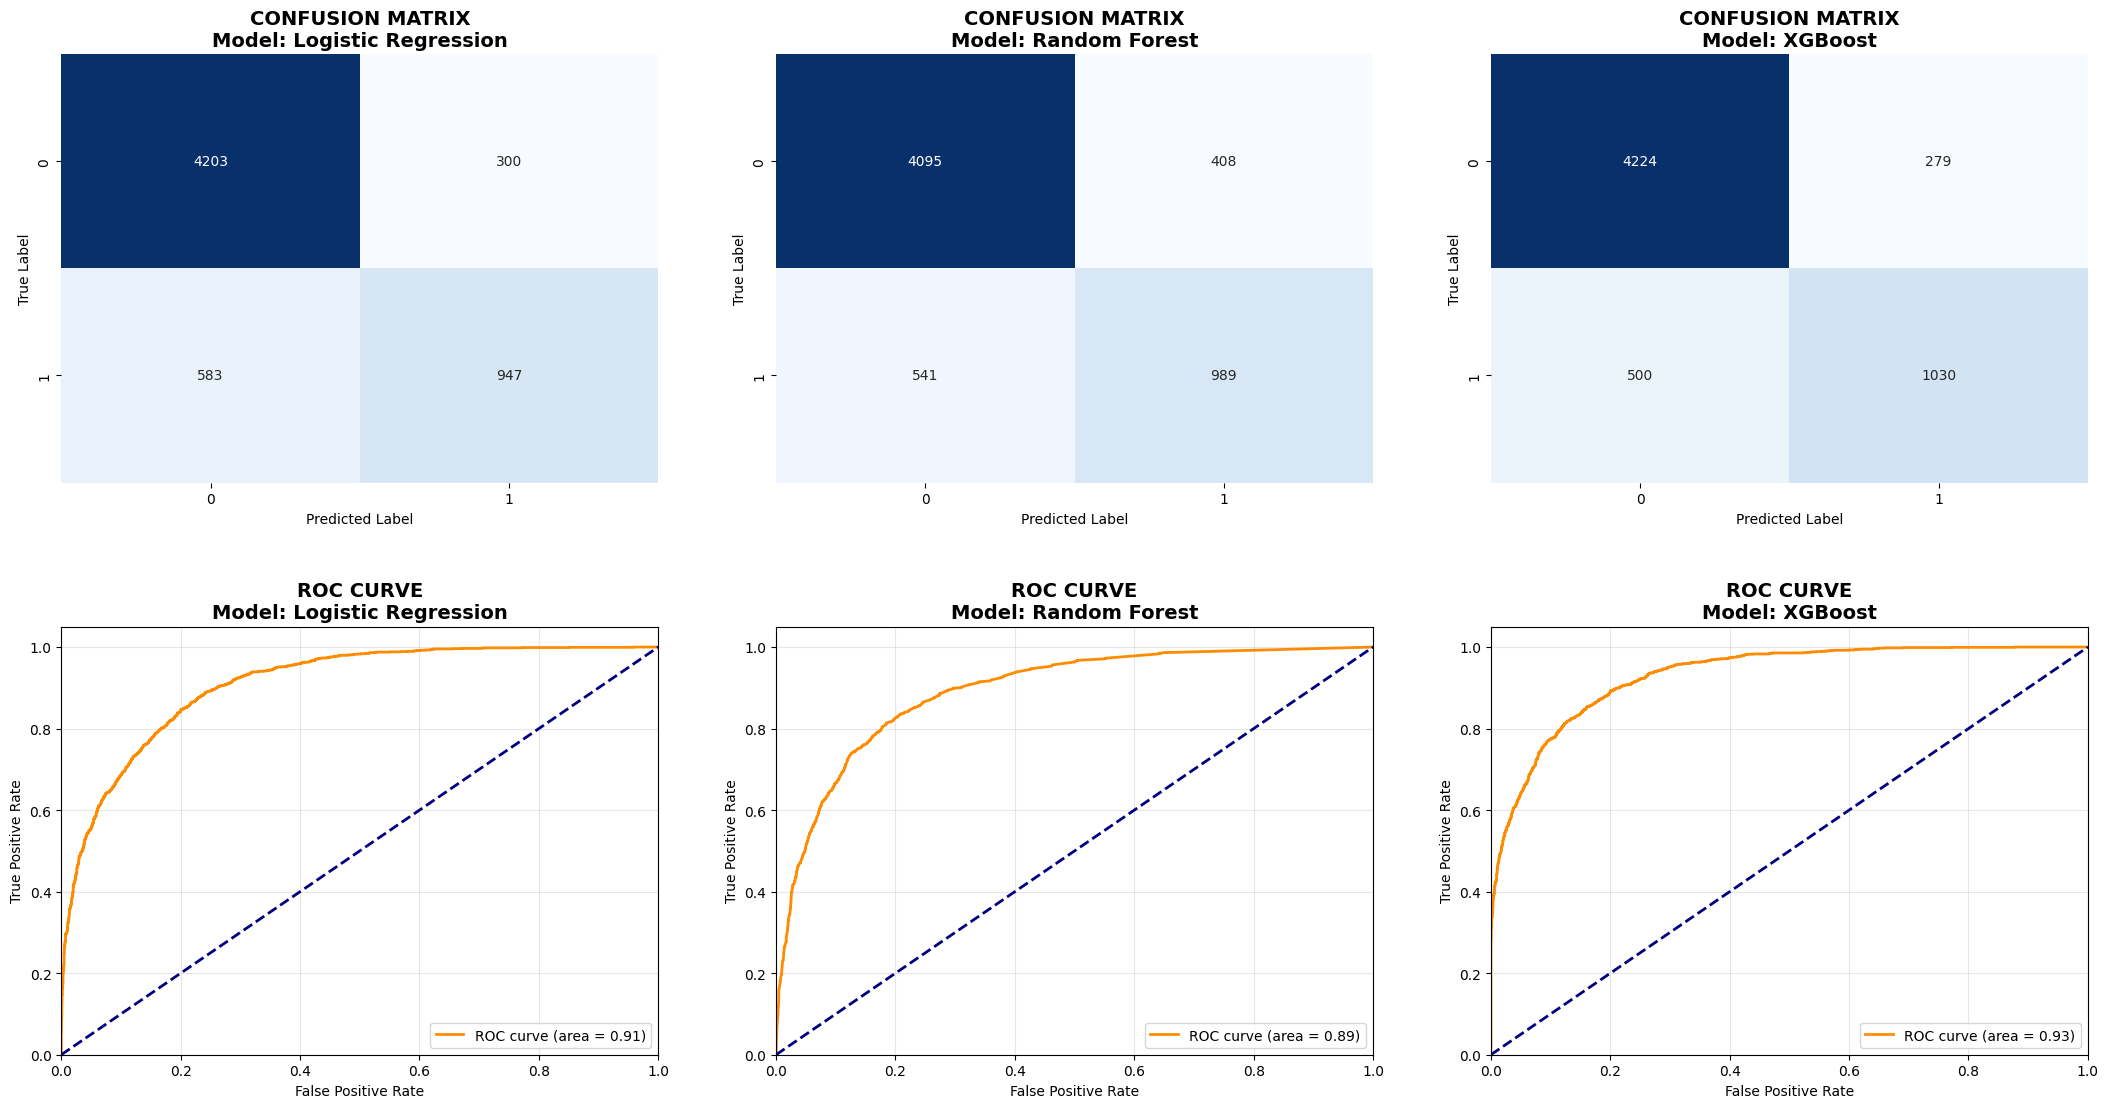

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Create a figure with 2 rows (CM on top, ROC on bottom) and 3 columns (one for each model)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

results = []

for idx, (name, model) in enumerate(models.items()):
    # 1. Pipeline and Prediction
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    start_train = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = clf.predict(X_test)
    test_time = time.time() - start_test

    y_probs = clf.predict_proba(X_test)[:, 1]

    # 2. Metrics Calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1, train_time, test_time])

    # --- ROW 1: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx], cbar=False)
    axes[0, idx].set_title(f'CONFUSION MATRIX\nModel: {name}', fontsize=14, fontweight='bold')
    axes[0, idx].set_xlabel('Predicted Label')
    axes[0, idx].set_ylabel('True Label')

    # --- ROW 2: Separate ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    axes[1, idx].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1, idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1, idx].set_xlim([0.0, 1.0])
    axes[1, idx].set_ylim([0.0, 1.05])
    axes[1, idx].set_xlabel('False Positive Rate')
    axes[1, idx].set_ylabel('True Positive Rate')
    axes[1, idx].set_title(f'ROC CURVE\nModel: {name}', fontsize=14, fontweight='bold')
    axes[1, idx].legend(loc="lower right")
    axes[1, idx].grid(alpha=0.3)

    # Print Text Report for Reference
    print(f"\nReport for {name}:")
    print(classification_report(y_test, y_pred))

plt.tight_layout(pad=4.0)
plt.show()

# **Hyperparameter Tuning and Cross-Validation**

To optimize the performance and generalization of our models, we will perform hyperparameter tuning using GridSearchCV. This systematic approach searches for the best combination of hyperparameters that maximize a chosen evaluation metric (F1-score in this case).

Following tuning, we will employ Stratified K-Fold Cross-Validation to ensure our models are robust and generalize well to unseen data, providing a more reliable estimate of their performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.1, 1.0, 10],
        'classifier__solver': ['lbfgs', 'liblinear']
    },
    "Random Forest": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7]
    }
}

grid_results = []
best_models = {}

print(f"{'Model Name':<25} | {'Acc':<7} | {'Prec':<7} | {'Rec':<7} | {'F1':<7}")
print("-" * 65)

for name, model in models.items():
    # Setup Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # GridSearchCV - optimizing for F1 to balance Precision and Recall
    grid_search = GridSearchCV(pipeline, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Store the best estimator
    best_clf = grid_search.best_estimator_
    best_models[name] = best_clf

    # Predict with the best version of the model
    y_pred = best_clf.predict(X_test)

    # Calculate all requested metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    grid_results.append([name, acc, prec, rec, f1])

    # Print real-time status
    print(f"{name:<25} | {acc:.4f} | {prec:.4f} | {rec:.4f} | {f1:.4f}")

# Convert results into a clean DataFrame for a full view
grid_summary_df = pd.DataFrame(grid_results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

Model Name                | Acc     | Prec    | Rec     | F1     
-----------------------------------------------------------------
Logistic Regression       | 0.8530 | 0.7582 | 0.6170 | 0.6804
Random Forest             | 0.8515 | 0.7334 | 0.6510 | 0.6898


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:53:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                   | 0.8747 | 0.7936 | 0.6837 | 0.7346


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_final_data = []

print("\nStarting Cross-Validation on Optimized Models...")

for name, optimized_model in best_models.items():
    # We use 'X' and 'y' (full dataset) for CV to see overall generalization
    cv_output = cross_validate(
        optimized_model, X, y, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        n_jobs=-1
    )

    cv_final_data.append({
        'Model': name,
        'Mean Acc': cv_output['test_accuracy'].mean(),
        'Mean Prec': cv_output['test_precision'].mean(),
        'Mean Rec': cv_output['test_recall'].mean(),
        'Mean F1': cv_output['test_f1'].mean(),
        'F1 Std Dev': cv_output['test_f1'].std() # Stability check
    })

# Final Summary Table
cv_summary_df = pd.DataFrame(cv_final_data)
print("\n" + "="*80)
print("FINAL CROSS-VALIDATION SUMMARY (AFTER HYPERPARAMETER TUNING)")
print("="*80)
print(cv_summary_df.round(4).to_string(index=False))
print("="*80)


Starting Cross-Validation on Optimized Models...

FINAL CROSS-VALIDATION SUMMARY (AFTER HYPERPARAMETER TUNING)
              Model  Mean Acc  Mean Prec  Mean Rec  Mean F1  F1 Std Dev
Logistic Regression    0.8470     0.7341    0.6044   0.6629      0.0077
      Random Forest    0.8507     0.7351    0.6263   0.6763      0.0083
            XGBoost    0.8703     0.7787    0.6693   0.7198      0.0079
